In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

print("✅ All imports successful")

✅ All imports successful


In [2]:
# Load preprocessed data from Phase 2
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nSample of y_train (target temperatures):")
print(y_train.head())

X_train shape: (6345, 91)
X_test shape:  (1587, 91)
y_train shape: (6345,)
y_test shape:  (1587,)

Sample of y_train (target temperatures):
0    28.3
1    30.4
2    18.9
3    28.3
4    29.5
Name: target_temp_max_d1, dtype: float64


In [3]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    
    # Skill score vs naive baseline
    naive_mae = mean_absolute_error(y_true, y_true.shift(1).fillna(y_true.mean()))
    skill = 1 - (mae / naive_mae)

    print(f"\n📊 {name} Results")
    print(f"  MAE:   {mae:.2f}°C")
    print(f"  RMSE:  {rmse:.2f}°C")
    print(f"  R²:    {r2:.3f}")
    print(f"  Skill: {skill:.3f}  (vs naive forecast)")
    
    return {"name": name, "mae": mae, "rmse": rmse, "r2": r2, "skill": skill}

print("✅ Evaluate function ready")

✅ Evaluate function ready


In [4]:
print("🚀 Training XGBoost... (takes 2-3 minutes)")

# Use 10% of training data for early stopping validation
val_size = int(len(X_train) * 0.1)
X_val = X_train.iloc[-val_size:]
y_val = y_train.iloc[-val_size:]
X_tr  = X_train.iloc[:-val_size]
y_tr  = y_train.iloc[:-val_size]

model_xgb = xgb.XGBRegressor(
    n_estimators          = 800,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    early_stopping_rounds = 30,
    eval_metric           = "mae",
    random_state          = 42,
    n_jobs                = -1,
)

model_xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

print("\n✅ XGBoost training complete!")

🚀 Training XGBoost... (takes 2-3 minutes)
[0]	validation_0-mae:3.56073
[100]	validation_0-mae:1.03879
[148]	validation_0-mae:1.04296

✅ XGBoost training complete!


In [5]:
# Predict on test set
y_pred_xgb = model_xgb.predict(X_test)

# Evaluate
results_xgb = evaluate("XGBoost", y_test, pd.Series(y_pred_xgb, index=y_test.index))


📊 XGBoost Results
  MAE:   0.99°C
  RMSE:  1.38°C
  R²:    0.911
  Skill: 0.788  (vs naive forecast)


In [6]:
import pickle
os.makedirs('../models', exist_ok=True)

# Save XGBoost model
with open('../models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(model_xgb, f)

# Save feature importance
importance = pd.Series(
    model_xgb.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

importance.to_csv('../models/feature_importance.csv')

print("✅ Model saved to models/xgboost_model.pkl")
print(f"\n🏆 Top 10 most important features:")
print(importance.head(10).to_string())

✅ Model saved to models/xgboost_model.pkl

🏆 Top 10 most important features:
temp_max_lag1               0.335418
temp_max                    0.288924
temp_mean_roll3_mean        0.110945
temp_mean                   0.058877
temp_max_lag2               0.012382
temp_max_lag3               0.008478
temp_max_lag7               0.007897
humidity_max                0.006795
humidity_mean_roll3_mean    0.006067
humidity_mean               0.005779


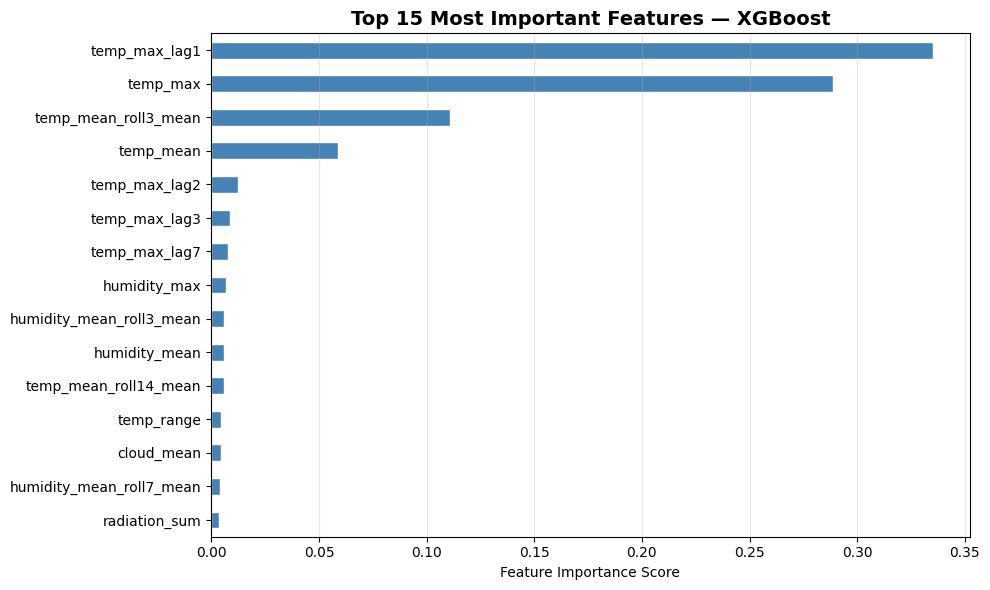

✅ Feature importance chart rendered


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

importance.head(15).plot(
    kind='barh', 
    ax=ax, 
    color='steelblue',
    edgecolor='white'
)

ax.set_title('Top 15 Most Important Features — XGBoost', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Feature importance chart rendered")

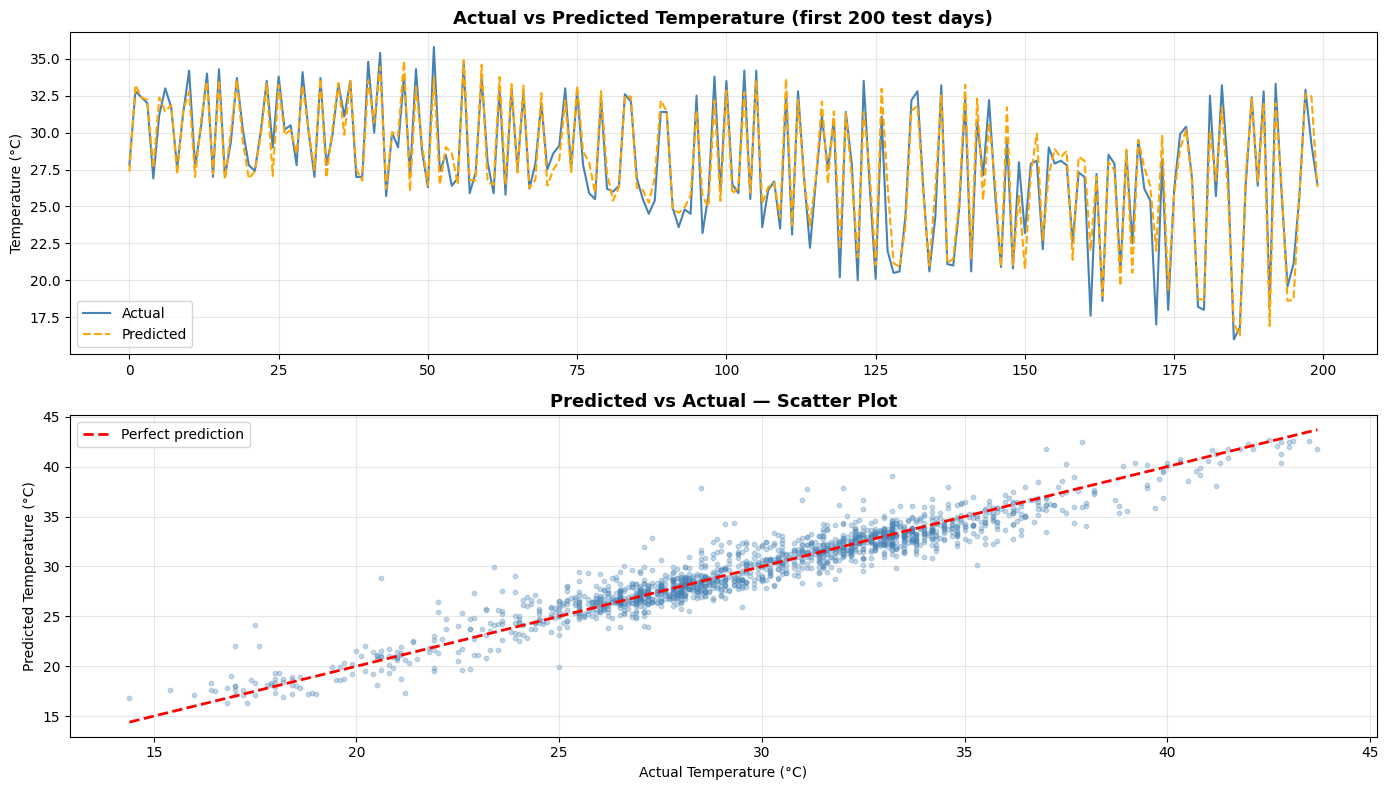

✅ Actual vs Predicted charts rendered


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1 — Actual vs Predicted over time
axes[0].plot(y_test.values[:200], label='Actual', color='steelblue', linewidth=1.5)
axes[0].plot(y_pred_xgb[:200], label='Predicted', color='orange', 
             linewidth=1.5, linestyle='--')
axes[0].set_title('Actual vs Predicted Temperature (first 200 test days)', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 — Scatter plot
axes[1].scatter(y_test.values, y_pred_xgb, alpha=0.3, color='steelblue', s=10)
axes[1].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect prediction')
axes[1].set_title('Predicted vs Actual — Scatter Plot', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Actual vs Predicted charts rendered")

In [11]:
import shutil
import os

# Copy scaler and feature_cols from data/ to models/
shutil.copy('../data/scaler.pkl', '../models/scaler.pkl')
shutil.copy('../data/feature_cols.pkl', '../models/feature_cols.pkl')

print("✅ Copied scaler and feature_cols to models/")

# Verify all model files exist
files = os.listdir('../models')
print("\n✅ Files in models/ folder:")
for f in files:
    size = os.path.getsize(f'../models/{f}')
    print(f"  {f} — {size/1024:.1f} KB")

print("\n🎉 Phase 3 complete! Ready to launch the dashboard.")

✅ Copied scaler and feature_cols to models/

✅ Files in models/ folder:
  feature_importance.csv — 2.7 KB
  xgboost_model.pkl — 608.7 KB
  feature_cols.pkl — 1.7 KB
  scaler.pkl — 4.3 KB

🎉 Phase 3 complete! Ready to launch the dashboard.
